In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

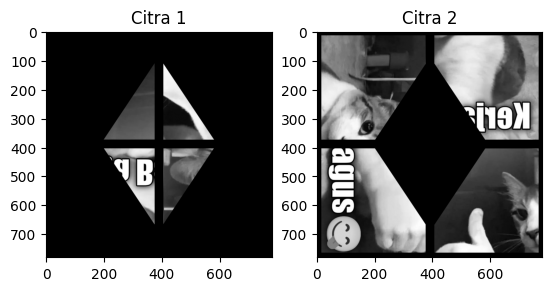

In [55]:
citra1 = cv2.imread('citra1.png')
citra_satu = cv2.cvtColor(citra1, cv2.COLOR_BGR2GRAY)

citra2 = cv2.imread('citra2.png')
citra_dua = cv2.cvtColor(citra2, cv2.COLOR_BGR2GRAY)

plt.subplot(1,2,1)
plt.imshow(citra_satu, cmap='gray')
plt.title("Citra 1")

plt.subplot(1,2,2)
plt.imshow(citra_dua, cmap='gray')
plt.title("Citra 2")

plt.show()

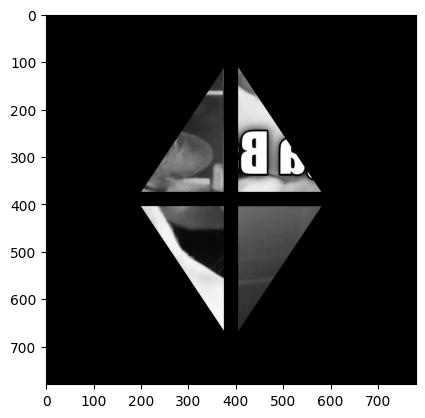

In [58]:
def fungsi_empat_R(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0:
        return image
    elif val == 90:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                rot[j, h - 1 - i] = image[i, j]
        return rot
    elif val == 180:
        rot = np.zeros_like(image, dtype=image.dtype)
        for i in range (h):
            for j in range(w):
                rot[h - 1 - i, w - 1 - j] = image[i, j]
        return rot
    elif val == 270:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range (h):
            for j in range(w):
                rot[w - 1 - j, i] = image[i, j]
        return rot
    return image

rotasi_satu = fungsi_empat_R(citra_satu, 180)
plt.imshow(rotasi_satu, cmap='gray')
plt.show()

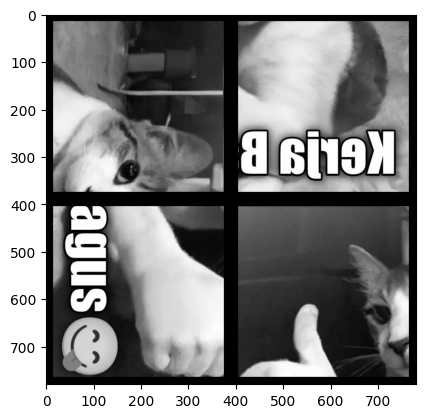

In [61]:
def fungsi_dua_a(citra_1, citra_2):
    return citra_1 + citra_2

merge_citra1 = fungsi_dua_a(rotasi_satu, citra_dua)
plt.imshow(merge_citra1, cmap='gray')
plt.show()


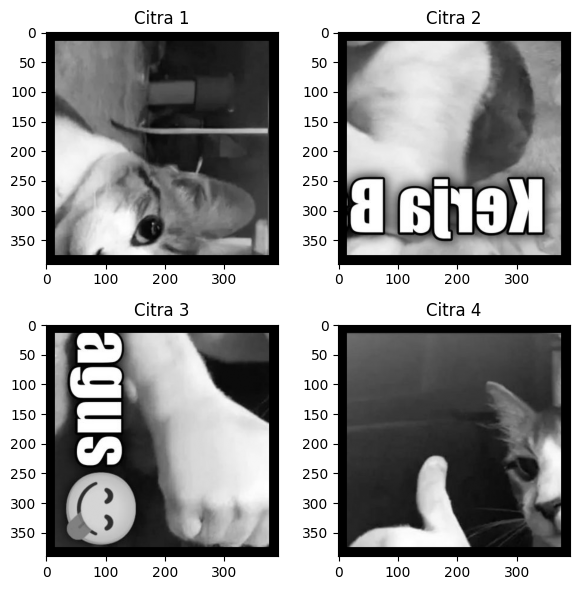

In [69]:
def split_horizontal(image, titik_awal, titik_akhir):
    return image[titik_awal:titik_akhir, :]

horizontal1 = split_horizontal(merge_citra1, 0, 390)
horizontal2 = split_horizontal(merge_citra1, 390, 780)

def split_vertikal(image, titik_awal, titik_akhir):
    return image[:, titik_awal:titik_akhir]

vertikal1 = split_vertikal(horizontal1, 0, 390)
vertikal2 = split_vertikal(horizontal1, 390, 780)
vertikal3 = split_vertikal(horizontal2, 0, 390)
vertikal4 = split_vertikal(horizontal2, 390, 780)

plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
plt.imshow(vertikal1, cmap='gray')
plt.title("Citra 1")
plt.axis('on')

plt.subplot(2,2,2)
plt.imshow(vertikal2, cmap='gray')
plt.title("Citra 2")
plt.axis('on')

plt.subplot(2,2,3)
plt.imshow(vertikal3, cmap='gray')
plt.title("Citra 3")
plt.axis('on')

plt.subplot(2,2,4)
plt.imshow(vertikal4, cmap='gray')
plt.title("Citra 4")
plt.axis('on')

plt.tight_layout()
plt.show()

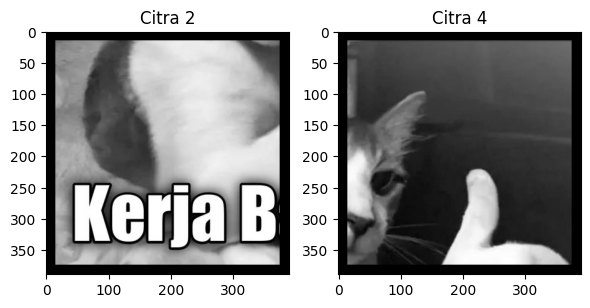

In [71]:
def fungsi_satu(image, mode='X'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[i, w - 1 - j]
            elif mode == 'Y':
                hasil[i, j] = image[h - 1 - i, j]
    return hasil

hasil_flip1 = fungsi_satu(vertikal2, 'X')
hasil_flip2 = fungsi_satu(vertikal4, 'X')

plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
plt.imshow(hasil_flip1, cmap='gray')
plt.title("Citra 2")
plt.axis('on')

plt.subplot(2,2,2)
plt.imshow(hasil_flip2, cmap='gray')
plt.title("Citra 4")
plt.axis('on')

plt.tight_layout()
plt.show()


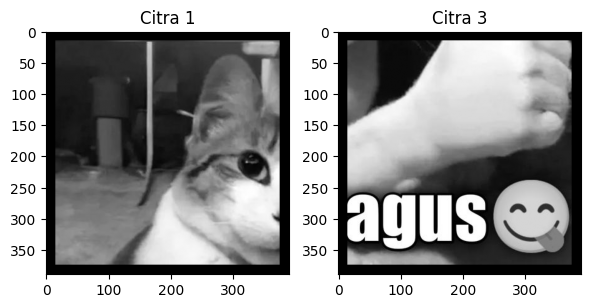

In [75]:
rotasi_dua = fungsi_empat_R(vertikal1, 270)
rotasi_tiga = fungsi_empat_R(vertikal3, 270)

plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
plt.imshow(rotasi_dua, cmap='gray')
plt.title("Citra 1")
plt.axis('on')

plt.subplot(2,2,2)
plt.imshow(rotasi_tiga, cmap='gray')
plt.title("Citra 3")
plt.axis('on')

plt.tight_layout()
plt.show()

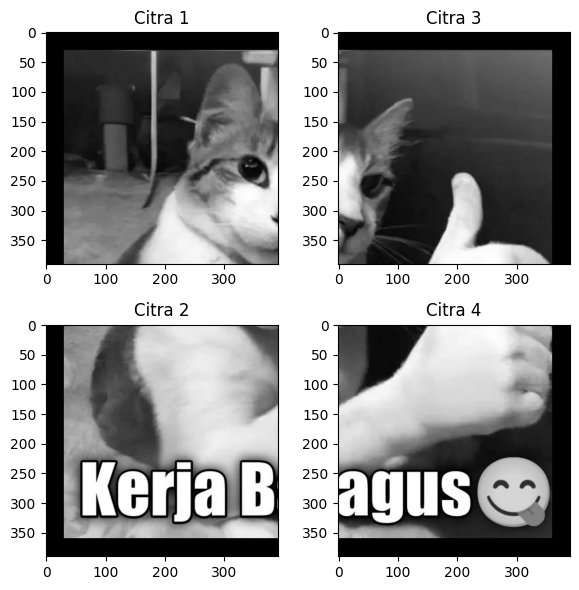

In [81]:
def fungsi_lima(image, geser_kolom_x=0, geser_baris_y=0):
    image = np.array(image)
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)

    for i in range(h):
        for j in range(w):
            new_i = i + geser_baris_y
            new_j = j + geser_kolom_x
            if 0 <= new_i < h and 0 <= new_j < w:
                hasil[new_i, new_j] = image[i, j]
    return hasil

translasi_citra1 = fungsi_lima(rotasi_dua, 15, 15)   
translasi_citra2 = fungsi_lima(hasil_flip2, -15, 15)
translasi_citra3 = fungsi_lima(hasil_flip1, 15, -15)   
translasi_citra4 = fungsi_lima(rotasi_tiga, -15, -15) 

plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
plt.imshow(translasi_citra1, cmap='gray')
plt.title("Citra 1")
plt.axis('on')

plt.subplot(2,2,2)
plt.imshow(translasi_citra2, cmap='gray')
plt.title("Citra 3")
plt.axis('on')

plt.subplot(2,2,3)
plt.imshow(translasi_citra3, cmap='gray')
plt.title("Citra 2")
plt.axis('on')

plt.subplot(2,2,4)
plt.imshow(translasi_citra4, cmap='gray')
plt.title("Citra 4")
plt.axis('on')

plt.tight_layout()
plt.show()

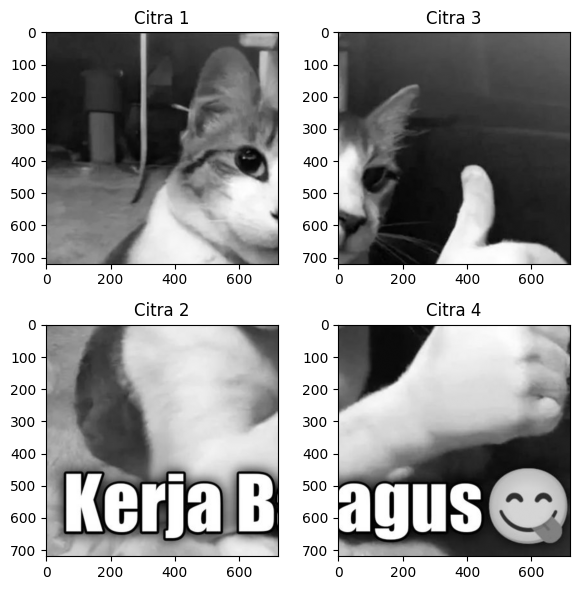

In [85]:
def fungsi_tiga(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
    dilated = np.zeros((h * 2, w * 2)).astype(int)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)] [int(x / 2)]
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    return dilated[sy:ey, sx:ex]

dilatasi_citra1 = fungsi_tiga(translasi_citra1, 60, 0, 60, 0)
dilatasi_citra2 = fungsi_tiga(translasi_citra2, 60, 0, 0, 60)
dilatasi_citra3 = fungsi_tiga(translasi_citra3, 0, 60, 60, 0)
dilatasi_citra4 = fungsi_tiga(translasi_citra4, 0, 60, 0, 60)

plt.figure(figsize=(6,6))

plt.subplot(2,2,1)
plt.imshow(dilatasi_citra1, cmap='gray')
plt.title("Citra 1")
plt.axis('on')

plt.subplot(2,2,2)
plt.imshow(dilatasi_citra2, cmap='gray')
plt.title("Citra 3")
plt.axis('on')

plt.subplot(2,2,3)
plt.imshow(dilatasi_citra3, cmap='gray')
plt.title("Citra 2")
plt.axis('on')

plt.subplot(2,2,4)
plt.imshow(dilatasi_citra4, cmap='gray')
plt.title("Citra 4")
plt.axis('on')

plt.tight_layout()
plt.show()

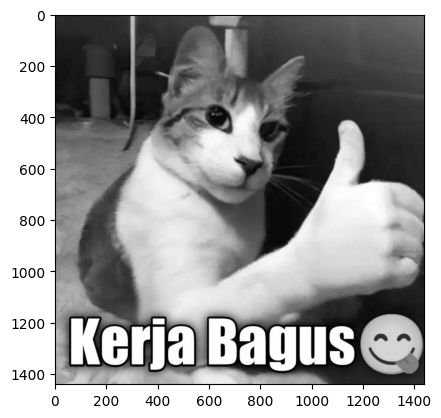

In [92]:
def fungsi_dua_b(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

def fungsi_dua_c(citra_1, citra_2):
    c1, c2 = np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil[0:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

atas = fungsi_dua_b(dilatasi_citra1, dilatasi_citra2)
bawah = fungsi_dua_b(dilatasi_citra3, dilatasi_citra4)
gabungan = fungsi_dua_c(atas, bawah)

def pembagi(image, pembagi=2):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            hasil[i, j] = int(image[i, j] / pembagi)

    return hasil

piksel_bagi = pembagi(gabungan)

plt.imshow(piksel_bagi, cmap='gray')
plt.axis('on')
plt.show()

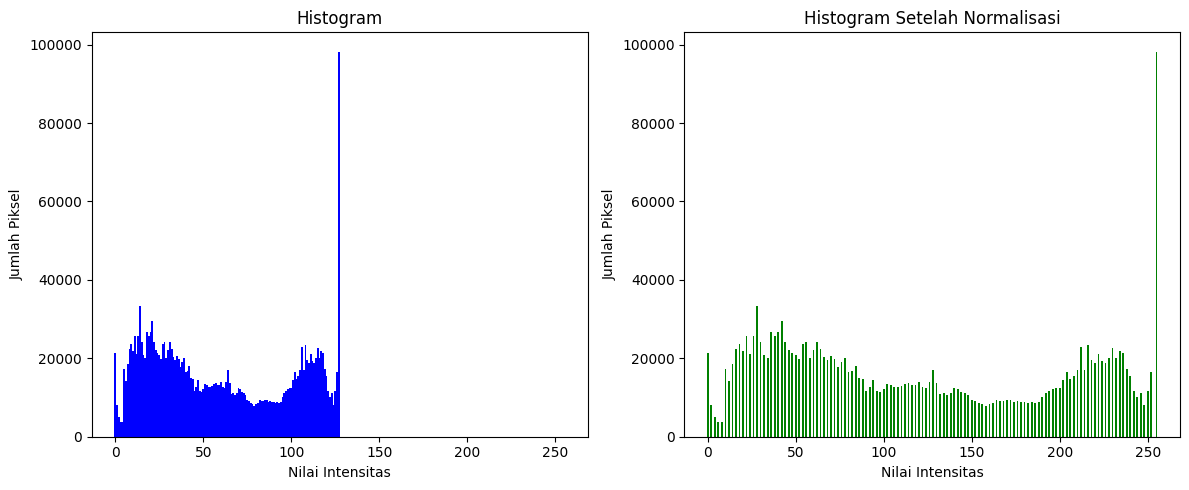

In [95]:
def hitung_histogram(image):
    h, w = image.shape
    hist = np.zeros(256, dtype=int)
    for i in range(h):
        for j in range(w):
            pixel = image[i, j]
            hist[pixel] += 1
    return hist

def normalisasi_citra(image):
    h, w = image.shape
    
    min_pixel = image[0, 0]
    max_pixel = image[0, 0]
    for i in range(h):
        for j in range(w):
            if image[i, j] < min_pixel:
                min_pixel = image[i, j]
            if image[i, j] > max_pixel:
                max_pixel = image[i, j]
    
    if max_pixel == min_pixel:
        return image
    
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            baru = (image[i, j] - min_pixel) / (max_pixel - min_pixel) * 255
            hasil[i, j] = int(baru)
    
    return hasil

hist_before = hitung_histogram(piksel_bagi)
citra_normal = normalisasi_citra(piksel_bagi)
hist_after = hitung_histogram(citra_normal)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(256), hist_before, width=1, color='blue')
plt.title("Histogram")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(1, 2, 2)
plt.bar(range(256), hist_after, width=1, color='green')
plt.title("Histogram Setelah Normalisasi")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()

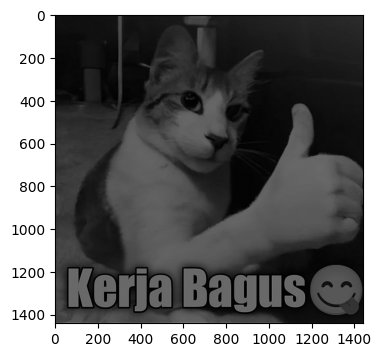

In [102]:
def zero_padding(image, pad):
    h, w = image.shape
    padded = np.zeros((h + 2*pad, w + 2*pad), dtype=image.dtype)

    padded[pad:pad+h, pad:pad+w] = image
    return padded

kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

def konvolusi(image, kernel):
    h, w = image.shape
    k = kernel.shape[0]
    pad = k // 2

    padded = zero_padding(image, pad)
    hasil = np.zeros((h, w))

    for i in range(h):
        for j in range(w):
            area = padded[i:i+k, j:j+k]
            hasil[i, j] = np.sum(area * kernel)

    return hasil

hasil_konvolusi = konvolusi(citra_normal, kernel)

hasil_clipping = np.zeros_like(hasil_konvolusi)

h, w = hasil_konvolusi.shape

for i in range(h):
    for j in range(w):
        if hasil_konvolusi[i, j] < 0:
            hasil_clipping[i, j] = 0
        elif hasil_konvolusi[i, j] > 255:
            hasil_clipping[i, j] = 255
        else:
            hasil_clipping[i, j] = hasil_konvolusi[i, j]

hasil_clipping = hasil_clipping.astype(np.uint8)

plt.figure(figsize=(10,4))
plt.imshow(hasil_clipping, cmap='gray')
plt.xticks(np.arange(0, 1401, 200))
plt.yticks(np.arange(0, 1401, 200))

plt.show()


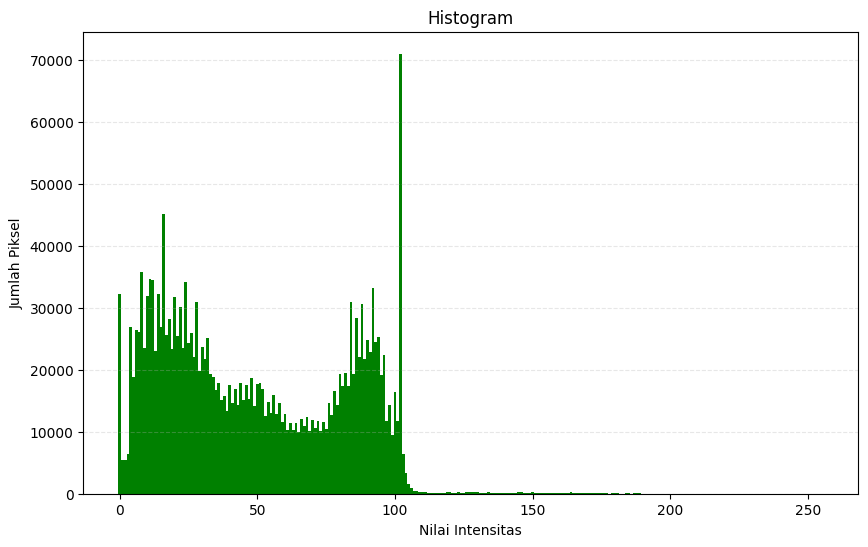

In [103]:
hist_final = np.zeros(256, dtype=int)
h, w = hasil_clipping.shape
for i in range(h):
    for j in range(w):
        hist_final[hasil_clipping[i, j]] += 1

plt.figure(figsize=(10, 6))
plt.bar(range(256), hist_final, color='green', width=1.0)
plt.title("Histogram")
plt.xlabel("Nilai Intensitas")
plt.ylabel("Jumlah Piksel")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()